In [2]:
# --- PART A ---
import pandas as pd
import sqlite3

results = pd.read_csv('https://raw.githubusercontent.com/martj42/international_results/master/results.csv')
shootouts = pd.read_csv('https://raw.githubusercontent.com/martj42/international_results/master/shootouts.csv')

conn = sqlite3.connect(':memory:')
results.to_sql('results', conn, index=False, if_exists='replace')
shootouts.to_sql('shootouts', conn, index=False, if_exists='replace')

675

In [11]:
pd.read_sql("SELECT * FROM results LIMIT 10", conn)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,0
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,0
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,0
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,0
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,0


In [25]:
# --- PART B ---
# B1:
b1 = pd.read_sql("""
    SELECT tournament, COUNT(*) AS tournament_matches
    FROM results
    GROUP BY tournament
    ORDER BY tournament_matches DESC
    LIMIT 10
""", conn)

b1

,tournament,tournament_matches
0,Friendly,18252
1,FIFA World Cup qualification,8771
2,UEFA Euro qualification,2824
3,African Cup of Nations qualification,2327
4,FIFA World Cup,964
5,Copa América,869
6,African Cup of Nations,845
7,AFC Asian Cup qualification,829
8,UEFA Nations League,658
9,CECAFA Cup,620


In [24]:
# B2:
b2 = pd.read_sql("""
    SELECT ROUND(AVG(home_score), 2) AS avg_home_score, ROUND(AVG(away_score), 2) AS avg_away_score
    FROM results
""", conn)

b2    

,avg_home_score,avg_away_score
0,1.76,1.18


In [15]:
pd.read_sql("SELECT * FROM shootouts LIMIT 10", conn)

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,None
1,1971-11-14,South Korea,Vietnam Republic,South Korea,None
2,1972-05-07,South Korea,Iraq,Iraq,None
3,1972-05-17,Thailand,South Korea,South Korea,None
4,1972-05-19,Thailand,Cambodia,Thailand,None
5,1973-04-21,Senegal,Ghana,Ghana,None
6,1973-06-14,Guinea,Mali,Guinea,None
7,1973-06-14,Mauritius,Tanzania,Mauritius,None
8,1973-07-26,Malaysia,Kuwait,Malaysia,None
9,1973-07-26,Cambodia,Singapore,Singapore,None


In [23]:
# B3:
b3 = pd.read_sql("""
    SELECT winner, COUNT(*) AS sum_shootout_wins
    FROM shootouts
    GROUP BY winner
    ORDER BY sum_shootout_wins DESC
    LIMIT 10
""", conn)

b3

,winner,sum_shootout_wins
0,South Korea,15
1,Egypt,15
2,Argentina,15
3,Zambia,14
4,Thailand,13
5,South Africa,13
6,Senegal,11
7,Iraq,11
8,Nigeria,10
9,Kenya,10


In [22]:
# B4: 
b4 = pd.read_sql("""
    SELECT date, home_team, away_team, shootouts.winner
    FROM results
    INNER JOIN shootouts
    USING(date, home_team, away_team)
""", conn)

b4

,date,home_team,away_team,winner
0,1967-08-22,India,Taiwan,Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea
2,1972-05-07,South Korea,Iraq,Iraq
3,1972-05-17,Thailand,South Korea,South Korea
4,1972-05-19,Thailand,Cambodia,Thailand
...,...,...,...,...
669,2026-03-30,Cape Verde,Finland,Cape Verde
670,2026-03-30,Gabon,Trinidad and Tobago,Gabon
671,2026-03-30,Uzbekistan,Venezuela,Uzbekistan
672,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina


In [28]:
# B5:
b5 = pd.read_sql("""
    SELECT country, COUNT(*) AS max_host
    FROM results
    INNER JOIN shootouts
    USING(date, home_team, away_team)
    GROUP BY country
    ORDER BY max_host DESC
    LIMIT 5
""", conn)

b5

,country,max_host
0,United States,41
1,South Africa,36
2,Thailand,26
3,Qatar,22
4,France,16


--- PART C ---

1. What does B4's JOIN actually do? Which rows get included, which get dropped, and why?
   
In B4 we use an INNER JOIN between results and shootouts, joining on the three columns they share: date, home_team, and away_team. This means only matches that appear in both tables are included in the result — specifically, only the 674 matches that went to a penalty shootout. All other matches that exist in results but have no corresponding row in shootouts are dropped, because INNER JOIN only keeps rows where a match is found on both sides. We then select winner from shootouts to show which team won each shootout.


2. Looking at B3 and B5 together — is there anything interesting or surprising in the results? What might explain it?

A notable pattern is that South Africa appears in the top 5 of both tables — 6th in shootout wins (B3) and 2nd in shootout matches hosted (B5). This is not a coincidence. Countries that host more tournaments play more matches on home soil, which means more overall chances to reach a shootout situation. So South Africa's high shootout win count is partly explained by volume — they simply appear in more shootout matches than most countries, both as host and as participant. This is a good reminder that raw counts can reflect opportunity as much as skill.

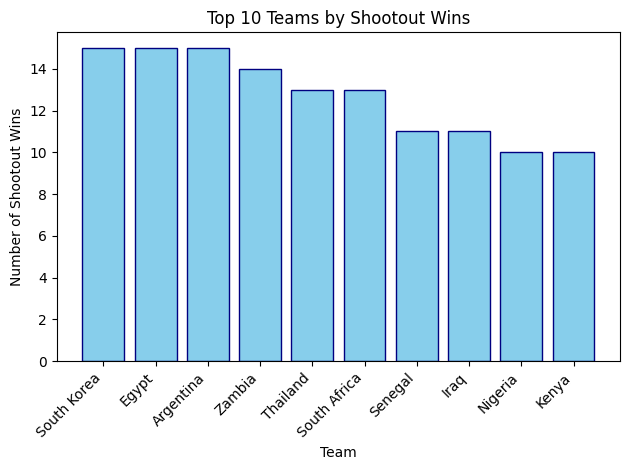

In [30]:
# --- PART D ---
import matplotlib.pyplot as plt

# Plotting the data
plt.bar(b3['winner'], b3['sum_shootout_wins'], color='skyblue', edgecolor='navy')

# Adding labels and title
plt.xlabel('Team')
plt.ylabel('Number of Shootout Wins')
plt.title('Top 10 Teams by Shootout Wins')

# Improving readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Display
plt.show()